### Theory

Assumption: The data is linearly separable

Training: It finds a separating hyperplane x*w + b = 0 where w: weights, b: bias

Prediction: For a test point, class label is assigned based on side of the hyperplane to which it lies. pred = step(x@w + b) where step(x) = 1 if x>0 else 0

### Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(3)

In [3]:
def accuracy(y, y_pred):
    return np.mean(y == y_pred)

class Perceptron:
    
    def __init__(self, epochs = 100):
        self.X = None
        self.y = None
        self.weights = None
        self.bias = None
        self.epochs = epochs

    def _step(self, val):
        return (val >= 0).astype(int)                                   # 1 if val >= 0 else 0

    def _initialise_weights(self, n_features):
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

    def fit(self, X, y):
        self.X = X
        self.y = y
        
        n_samples, n_features = self.X.shape

        self._initialise_weights(n_features)
        
        for epoch in range(self.epochs):
            
            misclassif = 0                # counter for misclassifications in an epoch

            for j in range(n_samples):
                x_i = self.X[j]
                y_i = self.y[j]
                y_pred = self._step( x_i @ self.weights + self.bias)   # y_pred = step(linear_output)
                diff = y_i - y_pred
                if diff != 0:             # if a sample is misclassified, update weights, bias, counter
                    self.weights += diff * x_i
                    self.bias += diff
                    misclassif += 1

            if misclassif == 0:              # at the end of an epoch if there has been no misclassification, the model has converged
                print(f'Converged at epoch = {epoch+1} for weight = {self.weights}, bias = {self.bias}')
                return
                

        print(f'Convergence did not reach within {self.epochs} epochs') 
        return


    def predict(self, X):
        return self._step(X @ self.weights + self.bias)
                 

In [4]:
import numpy as np

def generate_blobs(mean1 = [4,8], covar1 = [[.8, 1], [.25, 1]], mean2 = [12, 8], covar2 = [[.8, -.5], [2, .1]], samples_per_class = 400):
    
    # generate data for binary classification
                
    data1 = np.random.multivariate_normal(mean1, covar1, samples_per_class, 'ignore') # first gaussian
    label1 = np.ones(samples_per_class)
    
    data2 = np.random.multivariate_normal(mean2, covar2, samples_per_class, 'ignore') # second gaussian
    label2 = np.zeros(samples_per_class)   
    
    X = np.vstack((data1, data2))
    y = np.concatenate((label1,label2))

    return X, y


In [5]:
X, y = generate_blobs()

In [6]:
train_ids = np.random.rand(len(X)) >= .8
test_ids = ~(train_ids)

In [7]:
X_train, y_train, X_test, y_test = X[train_ids], y[train_ids], X[test_ids], y[test_ids]

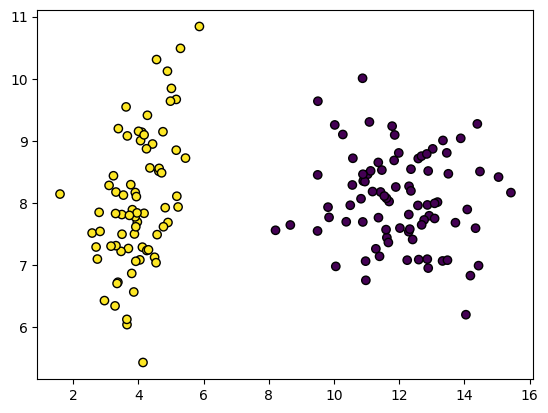

In [8]:
plt.scatter(X_train[:,0], X_train[:,1], c = y_train, edgecolor = 'k')

In [9]:
clf = Perceptron(100)
clf.fit(X_train, y_train)

Converged at epoch = 5 for weight = [-17.44518602  13.8137503 ], bias = 2.0


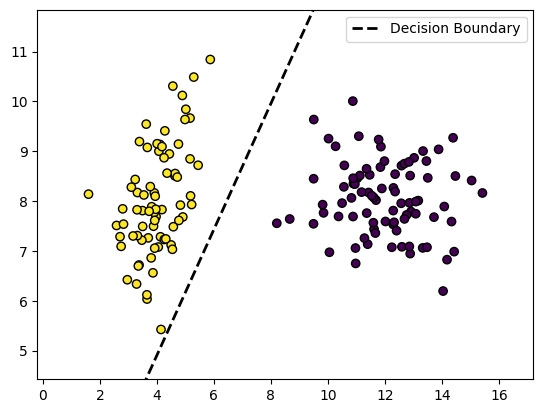

In [10]:
# Visualisation Option - 1

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

# Calculate decision boundary line: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
x_vals = np.array([x_min, x_max])
y_vals = -(clf.weights[0] * x_vals + clf.bias) / clf.weights[1]

plt.plot(x_vals, y_vals, 'k--', linewidth=2, label="Decision Boundary")
plt.ylim(y_min, y_max)
plt.legend()
plt.show()

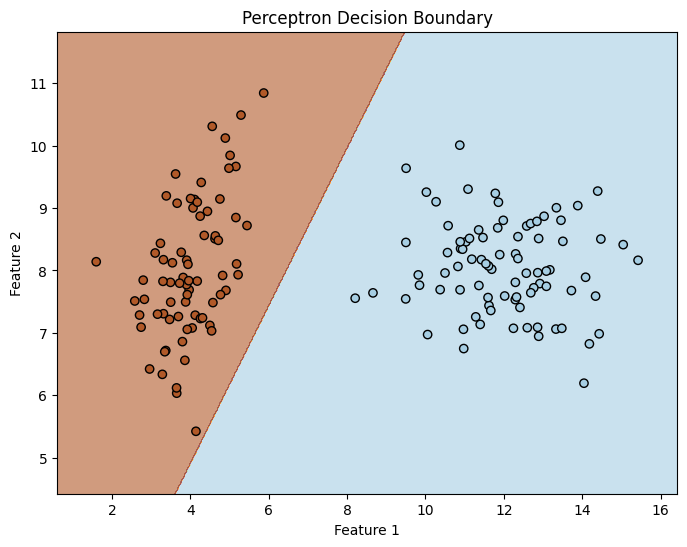

In [11]:
# Visualisation Option - 2


import numpy as np
import matplotlib.pyplot as plt

# 1. Define plot boundaries using X_train
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
h = 0.02  # Meshgrid step size

# 2. Create coordinate grid
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 3. Stack grid points into (N, 2) array and predict using clf.predict()
grid_points = np.c_[xx.ravel(), yy.ravel()]
z1 = clf.predict(grid_points)

# 4. Reshape predictions back to 2D grid shape
z1 = z1.reshape(xx.shape)

# 5. Plot decision region and training points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, z1, cmap=plt.cm.Paired, alpha=0.6)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Paired)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")
plt.show()

In [12]:
y_test_pred = clf.predict(X_test)

In [13]:
accuracy(y_test, y_test_pred)

np.float64(1.0)

In [14]:
# sklearn implementation

from sklearn.linear_model import Perceptron

clf2 = Perceptron()

clf2.fit(X_train, y_train)

y_test_pred2 = clf2.predict(X_test)

accuracy(y_test, y_test_pred2)

np.float64(1.0)

### Notes

Perceptron convergence proof